### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

### Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.

Se utilizó como dataset el libro **El Túnel** de E. Sábato.

Editorial:  
El túnel es una de las grandes novelas sudamericanas del siglo XX, cuyos ecos recogieron pronto en Europa Graham Greene y Camus. El relato, montado en los recursos de la novela policial, desarrolla un personaje que revela su psicología introspectiva e impone al lector un análisis de la desesperanza. El protagonista, Juan Pablo Castel, persigue inútilmente lo inalcanzable, que no es sino el regreso a la infancia, simbolizada en la ventana de un cuadro, motivo reiterado largamente en la narración.

In [70]:
import sys

if 'google.colab' in sys.modules:
    print("Entorno Colab detectado. Asegurando instalación de Gensim...")
    !pip install -q gensim

In [71]:
import os
import requests
import pandas as pd
from nltk.tokenize import RegexpTokenizer
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
import itertools
import multiprocessing
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import plotly.express as px

In [54]:
# Descarga el contenido del libro "El túnel" de Ernesto Sabato desde github

url = "https://raw.githubusercontent.com/mgonzalez738/desafios_procesamiento_lenguaje_natural/main/eltunel.txt"
filename = "eltunel.txt"

if not os.path.exists(filename):
    print(f"Archivo '{filename}' no encontrado. Descargando...")
    try:
        response = requests.get(url)
        response.raise_for_status()  # Verifica si la descarga fue exitosa
        with open(filename, "wb") as f:
            f.write(response.content)
        print("Descarga completada con éxito.")
    except Exception as e:
        print(f"Error al descargar: {e}")
else:
    print(f"El archivo '{filename}' ya existe en el directorio.")

El archivo 'eltunel.txt' ya existe en el directorio.


In [55]:
# Importa el txt de las oraciones del libro usando read_csv
df = pd.read_csv('eltunel.txt', sep='\t', header=None, names=['Sentence'])

# Visualización de una muestra de las oraciones
pd.set_option('display.max_colwidth', None)
display(df.head(5).style.set_properties(**{'text-align': 'left'}))

print("Cantidad de oraciones:", df.shape[0])

,Sentence
0,"BASTARÁ decir que soy Juan Pablo Castel, el pintor que mató a María Iribarne; supongo que el proceso está en el recuerdo de todos y que no se necesitan mayores explicaciones sobre mi persona."
1,"Aunque ni el diablo sabe qué es lo que ha de recordar la gente, ni por qué."
2,"En realidad, siempre he pensado que no hay memoria colectiva, lo que quizá sea una forma de defensa de la especie humana."
3,"La frase ""todo tiempo pasado fue mejor"" no indica que antes sucedieran menos cosas malas, sino que —felizmente— la gente las echa en el olvido."
4,"Desde luego, semejante frase no tiene validez universal; yo, por ejemplo, me caracterizo por recordar preferentemente los hechos malos y, así, casi podría decir que ""todo tiempo pasado fue peor"", si no fuera porque el presente me parece tan horrible como el pasado; recuerdo tantas calamidades, tantos rostros cínicos y crueles, tantas malas acciones, que la memoria es para mí como la temerosa luz que alumbra un sórdido museo de la vergüenza."


Cantidad de oraciones: 1646


In [56]:
# Instancia el tokenizador RegEx de NLTK
tokenizer = RegexpTokenizer(r'\w+') # Agrupa solo caracteres alfanuméricos, incluye tildes y ñ.
    
# Función para extraer palabras de las oraciones
def nltk_process(sentence):
    sentence_lower = str(sentence).lower()      # Pasa a minúsculas para igualar todo
    words = tokenizer.tokenize(sentence_lower)  # Extrae las palabras unicamente de cada oración
    return words

# Aplica la función a todas las oraciones del dataset y genera una lista de listas de palabras
sentence_tokens = df['Sentence'].apply(nltk_process).tolist()

# Impresión de la primera oración tokenizada
sentence_tokens[:1]

[['bastará',
  'decir',
  'que',
  'soy',
  'juan',
  'pablo',
  'castel',
  'el',
  'pintor',
  'que',
  'mató',
  'a',
  'maría',
  'iribarne',
  'supongo',
  'que',
  'el',
  'proceso',
  'está',
  'en',
  'el',
  'recuerdo',
  'de',
  'todos',
  'y',
  'que',
  'no',
  'se',
  'necesitan',
  'mayores',
  'explicaciones',
  'sobre',
  'mi',
  'persona']]

In [57]:
# Crea el modelo generador de vectores
w2v_model = Word2Vec(min_count=2,      # Frecuencia mínima de palabra para incluirla en el vocabulario
                     window=4,         # Cantidad de palabras antes y desp de la predicha
                     vector_size=200,  # Dimensionalidad de los vectores
                     negative=20,      # Cantidad de negative samples... 0 es no se usa
                     workers=1,        # Si tienen más cores pueden cambiar este valor
                     sg=1)             # modelo 0:CBOW  1:skipgram

In [58]:
# Busca los mejores parametros para el modelo Word2Vec usando multiprocessing y GridSearch

cores = multiprocessing.cpu_count()
epochs = 50

# Define la grilla de parámetros a probar para seleccionar los mejores
param_grid = {
    'vector_size': [50, 100, 200],     # Dimensionalidad de los vectores
    'window': [3, 5, 7]                # Cantidad de palabras antes y desp de la predicha
}

# Genera todas las combinaciones posibles
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_loss = float('inf')
best_params = None

# Prueba cada combinación de parámetros, entrena el modelo y evalúa el loss
print(f"Prueba alternativas de parametrós con {epochs} epochs usando {cores} cores.")

for params in combinations:
    print(f"Probando: {params}")
    model = Word2Vec(min_count=2,          # Frecuencia mínima de palabra para incluirla en el vocabulario
                     negative=15,          # Cantidad de negative samples
                     workers=cores, 
                     compute_loss=True, 
                     sg=1,                 # Modelo 0:CBOW  1:skipgram
                     **params)
    model.build_vocab(sentence_tokens)
    model.train(sentence_tokens, total_examples=model.corpus_count, epochs=epochs, compute_loss=True)
    
    current_loss = model.get_latest_training_loss()
    if current_loss < best_loss:
        best_loss = current_loss
        best_params = params

print(f"Mejores parámetros encontrados: {best_params} con pérdida acumulada: {best_loss}")

Prueba alternativas de parametrós con 50 epochs usando 24 cores.
Probando: {'vector_size': 50, 'window': 3}
Probando: {'vector_size': 50, 'window': 5}
Probando: {'vector_size': 50, 'window': 7}
Probando: {'vector_size': 100, 'window': 3}
Probando: {'vector_size': 100, 'window': 5}
Probando: {'vector_size': 100, 'window': 7}
Probando: {'vector_size': 200, 'window': 3}
Probando: {'vector_size': 200, 'window': 5}
Probando: {'vector_size': 200, 'window': 7}
Mejores parámetros encontrados: {'vector_size': 100, 'window': 3} con pérdida acumulada: 3156533.25


Cantidad de words distintas en el corpus: 2300
Iniciando entrenamiento...
Época 0 -> Pérdida Época: 132,514.89 | Total Acumulada: 132,514.89
Época 1 -> Pérdida Época: 85,472.56 | Total Acumulada: 217,987.45
Época 2 -> Pérdida Época: 81,711.52 | Total Acumulada: 299,698.97
Época 3 -> Pérdida Época: 81,170.16 | Total Acumulada: 380,869.12
Época 4 -> Pérdida Época: 81,387.34 | Total Acumulada: 462,256.47
Época 5 -> Pérdida Época: 81,470.66 | Total Acumulada: 543,727.12
Época 6 -> Pérdida Época: 81,340.25 | Total Acumulada: 625,067.38
Época 7 -> Pérdida Época: 80,716.75 | Total Acumulada: 705,784.12
Época 8 -> Pérdida Época: 78,721.25 | Total Acumulada: 784,505.38
Época 9 -> Pérdida Época: 77,635.00 | Total Acumulada: 862,140.38
Época 10 -> Pérdida Época: 78,760.38 | Total Acumulada: 940,900.75
Época 11 -> Pérdida Época: 77,294.62 | Total Acumulada: 1,018,195.38
Época 12 -> Pérdida Época: 71,779.00 | Total Acumulada: 1,089,974.38
Época 13 -> Pérdida Época: 70,344.38 | Total Acumulada: 1,16

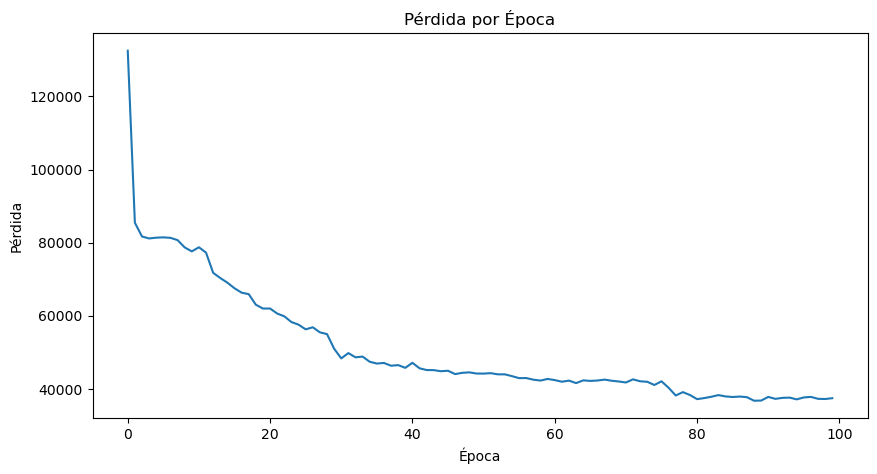

In [59]:
# Entrena el modelo con los mejores parámetros encontrados y doble de epocas

w2v_model = Word2Vec(min_count=2,
                     negative=15, 
                     workers=cores,
                     compute_loss=True, 
                     sg=1,
                     window=best_params['window'],          
                     vector_size=best_params['vector_size'])         

# Construye el vocabulario
w2v_model.build_vocab(sentence_tokens)

# Cantidad de palabras encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

# Callback para imprimir el loss por epoca
class LossCallback(CallbackAny2Vec):
    def __init__(self):
        self.losses = []
        self.epoch = 0
        self.loss_previous_step = 0

    def on_train_begin(self, model):
        self.epoch = 0
        self.loss_previous_step = 0
        print("Iniciando entrenamiento...")

    def on_epoch_end(self, model):
        # Obtiene la pérdida total acumulada que reporta Gensim
        cumulative_loss = model.get_latest_training_loss()
        
        # Calcula la pérdida específica de esta época (la resta)
        if self.epoch == 0:
            current_loss = cumulative_loss
        else:
            current_loss = cumulative_loss - self.loss_previous_step
        
        # Guarda la de la época para el gráfico
        self.losses.append(current_loss)
        
        # Imprime ambas métricas
        print(f"Época {self.epoch} -> Pérdida Época: {current_loss:,.2f} | Total Acumulada: {cumulative_loss:,.2f}")
        
        # 5. Actualiza el estado para la próxima vuelta
        self.loss_previous_step = cumulative_loss
        self.epoch += 1

# Entrena
monitor = LossCallback()
w2v_model.train(sentence_tokens,
                total_examples=w2v_model.corpus_count,
                epochs=2*epochs, 
                compute_loss=True,
                callbacks=[monitor])

plt.figure(figsize=(10, 5))
plt.plot(monitor.losses)
plt.title("Pérdida por Época")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.show()

### Elegir términos de interés y buscar términos más similares y menos similares.

In [60]:
w2v_model.wv.most_similar(positive=["maría"], topn=10)

[('querida', 0.6085999011993408),
 ('prostituta', 0.4360082149505615),
 ('puta', 0.3943200707435608),
 ('mortalmente', 0.3936963677406311),
 ('intuí', 0.36742594838142395),
 ('iribarne', 0.365705668926239),
 ('maté', 0.36411619186401367),
 ('debió', 0.3618713319301605),
 ('simulaba', 0.3577852249145508),
 ('instantáneamente', 0.35733866691589355)]

Hay similitud con términos que podrían interpretarse como los sentimientos de Castel por María, mayormente ausente, como se convence que es una prostituta y su asesinato. 

In [61]:
w2v_model.wv.most_similar(positive=["playa"], topn=10)

[('solitaria', 0.7105937600135803),
 ('pedazos', 0.6543317437171936),
 ('caminos', 0.6474928259849548),
 ('extraños', 0.619636058807373),
 ('inútiles', 0.6050499677658081),
 ('sala', 0.6008134484291077),
 ('sucia', 0.5930591225624084),
 ('fijamente', 0.5867840647697449),
 ('caía', 0.58393794298172),
 ('agua', 0.5800346732139587)]

Hay similitud con palabras asociados a la playa del cuadro: caminos, solitaria, sala.

In [62]:
w2v_model.wv.most_similar(negative=["amor"], topn=10)

[('examen', 0.07696648687124252),
 ('preguntó', 0.030012860894203186),
 ('podría', 0.02439139224588871),
 ('quien', 0.02332812361419201),
 ('diré', 0.021734727546572685),
 ('mapelli', 0.018754292279481888),
 ('salir', 0.016568776220083237),
 ('asombrado', 0.013164650648832321),
 ('bastante', 0.011972571723163128),
 ('nuevamente', 0.006935874465852976)]

No se ve relacion entre amor y esas palabras.

In [63]:
w2v_model.wv.most_similar(negative=["casa"], topn=10)

[('crueles', 0.07317077368497849),
 ('forman', 0.07212609797716141),
 ('charlatanes', 0.057845234870910645),
 ('sucede', 0.02930595353245735),
 ('vanidad', 0.027457822114229202),
 ('hubo', 0.022604042664170265),
 ('peores', 0.02219841629266739),
 ('habían', 0.02171378768980503),
 ('dio', 0.020933127030730247),
 ('situaciones', 0.019387124106287956)]

No se ve relacion entre casa y esas palabras.

In [64]:
w2v_model.wv.most_similar(positive=["maría", "hunter"], topn=10)

[('querida', 0.6380340456962585),
 ('indisposición', 0.5113580822944641),
 ('severidad', 0.5079415440559387),
 ('quieras', 0.5046034455299377),
 ('instantáneamente', 0.5023981332778931),
 ('indiferencia', 0.48949769139289856),
 ('celos', 0.47768285870552063),
 ('va', 0.4772937595844269),
 ('física', 0.47176164388656616),
 ('vigilé', 0.46752336621284485)]

Interesante, aparecen amante y celos que es lo que imagina el protagonista.

### Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.

In [65]:
# Función para reducir las dimensiones de los vectores de palabras usando t-SNE

def reduce_dimensions(model, num_dimensions = 2 ):

    # Extrae los vectores y las etiquetas de las palabras del modelo
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    # Configura t-SNE a 2 diemnsiones para visualización y obtiene los vectores
    tsne = TSNE(n_components=num_dimensions, random_state=42)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [66]:
# Grafica los primeros 200 vectores con sus etiquetas para evitar saturar la visualización

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS = 200

# 1. Creamos el scatter inicial
fig = px.scatter(
    x=vecs[:MAX_WORDS, 0], 
    y=vecs[:MAX_WORDS, 1], 
    text=labels[:MAX_WORDS],
    template="plotly_white" 
)

fig.update_traces(
        textposition='top center', 
        marker=dict(size=12, color='#D90404', line=dict(width=1, color='#333333')),
        textfont=dict(family="Arial", size=10, color="black"),
        cliponaxis=False 
)

fig.update_layout(
    width=1200,   # Más angosta
    height=600, # Más alta
    xaxis=dict(showgrid=True, zeroline=True, title="Eje X"),
    yaxis=dict(showgrid=True, zeroline=True, title="Eje Y"),
    margin=dict(l=40, r=40, t=20, b=40),
    hovermode='closest'
)

fig.update_traces(cliponaxis=False)

fig.show(renderer="colab")

In [69]:
# Aplicamos t-SNE a un subconjunto de palabras relevantes del texto para enfocar en como se relacionan entre sí en el espacio vectorial, 
# lo que puede revelar agrupamientos temáticos o semánticos específicos del libro.

#  Definición de las 100 palabras relevantes del texto para graficar (obtenidas por Gemini)
target_words = [
    "juan", "pablo", "castel", "maría", "iribarne", "hunter", "allende", "mimí", "sabu", "lartigue", 
    "richard", "primo", "ciego", "ciegos", "túnel", "ventana", "cuadro", "maternidad", "playa", "mar", 
    "muelle", "puerto", "escena", "tela", "pintura", "artista", "bisturí", "cuchillo", "revólver", 
    "carta", "teléfono", "fósforo", "vidrio", "caja", "soledad", "angustia", "celos", "sospecha", 
    "odio", "amor", "desesperación", "locura", "miedo", "orgullo", "timidez", "vanidad", "indiferencia", 
    "crueldad", "cinismo", "tristeza", "náusea", "desprecio", "laberinto", "egoísmo", "maldad", "maté", 
    "matarla", "muerte", "encuentro", "búsqueda", "espera", "silencio", "grito", "llanto", "mentira", 
    "verdad", "traición", "confesión", "análisis", "razonamiento", "lógica", "entender", "comprender", 
    "incomprensión", "estancia", "campo", "ciudad", "taller", "sala", "exposición", "calle", "noche", 
    "sombra", "luz", "oscuridad", "abismo", "puente", "muro", "desierto", "tiempo", "vida", "destino", 
    "ceguera", "absoluto", "nada", "infinito", "realidad", "sueño", "pesadilla", "existencia", "alma", 
    "carne", "sangre", "fin"
]

def plot_word_list(model, lista_palabras):
    # Filtrado previo
    valid_labels = [w for w in lista_palabras if w in model.wv.key_to_index]
    valid_vectors = np.array([model.wv[w] for w in valid_labels])
    
    if len(valid_labels) == 0:
        print("No se encontraron palabras de la lista en el modelo.")
        return

    tsne = TSNE(n_components=2, random_state=42, perplexity=12, init='pca', learning_rate='auto')
    puntos = tsne.fit_transform(valid_vectors)
    
    # Creación del gráfico con Plotly
    fig = px.scatter(
        x=puntos[:, 0], 
        y=puntos[:, 1], 
        text=valid_labels,
        template="plotly_white",
        labels={'x': 'Dimensión t-SNE 1', 'y': 'Dimensión t-SNE 2'}
    )
    
    fig.update_traces(
        textposition='top center', 
        marker=dict(size=12, color='#D90404', line=dict(width=1, color='#333333')),
        textfont=dict(family="Arial", size=10, color="black"),
        cliponaxis=False 
    )

    fig.update_layout(
        width=1200,   # Más angosta
        height=600, # Más alta
        xaxis=dict(showgrid=True, zeroline=True, title="Eje X"),
        yaxis=dict(showgrid=True, zeroline=True, title="Eje Y"),
        margin=dict(l=40, r=40, t=20, b=40),
        hovermode='closest'
    )

    fig.show(renderer="colab")

plot_word_list(w2v_model, target_words)

En este grafico es mas sencillo encontrar grupos de palabras relacionadas.

![image.png](https://raw.githubusercontent.com/mgonzalez738/desafios_procesamiento_lenguaje_natural/main/Captura1.png)

Los nombres y apellido del protagonista

![image.png](https://raw.githubusercontent.com/mgonzalez738/desafios_procesamiento_lenguaje_natural/main/Captura2.png)

Hunter y celos

![image-2.png](https://raw.githubusercontent.com/mgonzalez738/desafios_procesamiento_lenguaje_natural/main/Captura3.png)

Cosas relacionadas razonamiento, realidad, pesadilla, locura, verdad, abismo, tristeza, sueño, confesion, analisis